#### Dowloading the data and importing important libraries/ modules
the new python convention encourages to import the subsidiary modules as and when required.

In [97]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Naina Bhatnagar\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
import os
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

In [100]:
df = pd.read_csv(full_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [102]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [103]:
num_df = df.select_dtypes(include=np.number)
cat_df = df.select_dtypes(include="object")
num_df.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


In [104]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
cat_arr_encoded = encoder.fit_transform(cat_df)
cat_df_encoded = pd.DataFrame(cat_arr_encoded, columns=encoder.get_feature_names_out())

cat_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex_female        1338 non-null   float64
 1   sex_male          1338 non-null   float64
 2   smoker_no         1338 non-null   float64
 3   smoker_yes        1338 non-null   float64
 4   region_northeast  1338 non-null   float64
 5   region_northwest  1338 non-null   float64
 6   region_southeast  1338 non-null   float64
 7   region_southwest  1338 non-null   float64
dtypes: float64(8)
memory usage: 83.8 KB


In [105]:
df_mod = num_df.join(cat_df_encoded)
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_female        1338 non-null   float64
 5   sex_male          1338 non-null   float64
 6   smoker_no         1338 non-null   float64
 7   smoker_yes        1338 non-null   float64
 8   region_northeast  1338 non-null   float64
 9   region_northwest  1338 non-null   float64
 10  region_southeast  1338 non-null   float64
 11  region_southwest  1338 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 125.6 KB


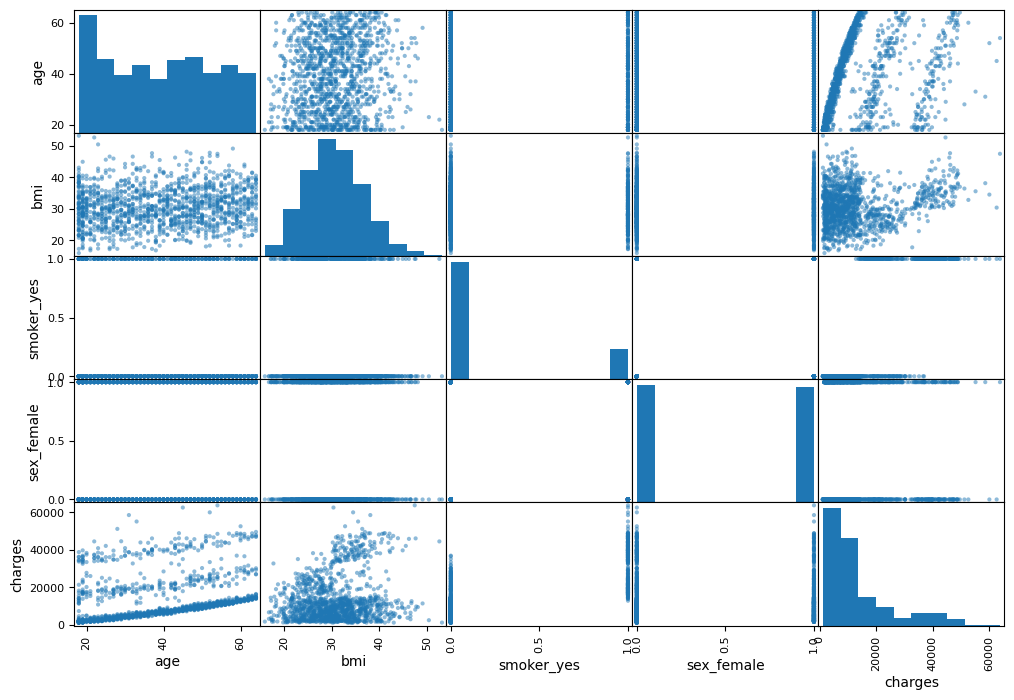

In [106]:
from pandas.plotting import scatter_matrix

feats = ["age","bmi","smoker_yes","sex_female","charges"]
scatter_matrix(df_mod[feats], figsize=(12,8))
plt.show()

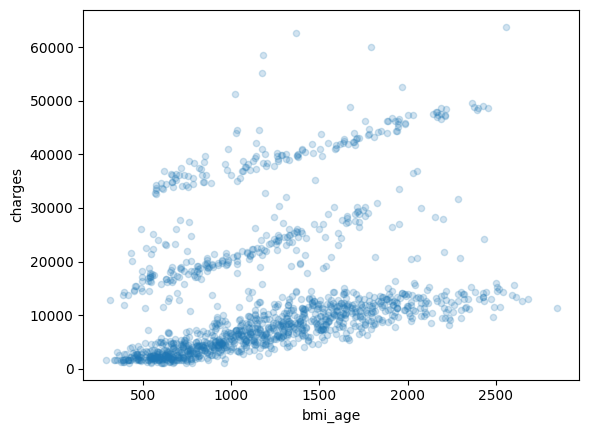

In [107]:
df_mod["bmi_age"] = df_mod["bmi"]*df_mod['age']
df_mod.plot(kind="scatter",y="charges",x="bmi_age", alpha=0.2)
plt.show()

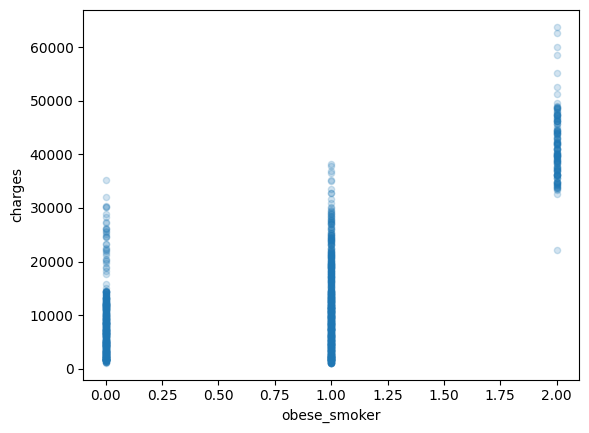

In [108]:
df_mod["obese"] = (df_mod["bmi"] >= 30).astype(int)
df_mod["obese_smoker"] = df_mod["obese"] + df_mod["smoker_yes"]
df_mod.plot(kind="scatter", x="obese_smoker", y="charges",alpha=0.2)
plt.show()


### Before any further investigations lets split the data into training and testing set.
we use sklearn.train_test_split() which selects random test cases with a given seed.

In [109]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,test_size=0.2, random_state=42)

In [110]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

num_pipeline = make_pipeline(SimpleImputer(strategy="median"),StandardScaler())
cat_pipeline = make_pipeline(OneHotEncoder())

In [111]:
from sklearn.compose import make_column_selector, make_column_transformer

col_tr = make_column_transformer(
    (num_pipeline,make_column_selector(dtype_include=np.number)),
    (cat_pipeline,make_column_selector(dtype_include=object))
)

In [112]:
# Let's add some new features
from sklearn.base import BaseEstimator, TransformerMixin

class FeatEngineeringNewFeats(BaseEstimator, TransformerMixin):
    def __init__(self, add_obese_smoker = True):
        self.add_obese_smoker = add_obese_smoker

    def fit(self,X,y=None):
        return self
    
    def transform(self,X):
        X_df = X.copy()

        if self.add_obese_smoker:
            is_obese = (X_df["bmi"] >= 30).astype(int)
            is_smoker = (X_df["smoker"] == "yes").astype(int)
            X_df["obese_smoker"] = is_obese + is_smoker

        return X_df

In [113]:
y = train["charges"]
X = train.drop("charges", axis=1)
test_y = test["charges"]
test_X = test.drop("charges", axis=1)

In [114]:
from sklearn.ensemble import RandomForestRegressor
model = make_pipeline(FeatEngineeringNewFeats(),col_tr,RandomForestRegressor(random_state=42))

In [115]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)
print("Mean Score:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())

Mean Score: 4944.613487676745
Standard Deviation: 530.1615048167153


In [116]:
model.fit(X,y)
test_pred = model.predict(test_X)

In [117]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(test_y,test_pred)
mse = mean_squared_error(test_y,test_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2579.13
RMSE: 4716.52
